In [1]:
!pip install -q -U transformers accelerate requests

import os
import json
import glob
import random
import torch
import torch.nn.functional as F
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
from transformers import AutoProcessor, LlavaForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 101.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.3

In [2]:
MODEL_NAME = "llava-hf/llava-1.5-7b-hf"

processor = AutoProcessor.from_pretrained(MODEL_NAME)
model = LlavaForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    max_memory={0: "12GiB", 1: "12GiB"},
)
model.eval()
for p in model.parameters():
    p.requires_grad_(False)

ln_f = model.model.language_model.norm
lm_head = model.lm_head

n_layer = model.config.text_config.num_hidden_layers
hidden_dim = model.config.text_config.hidden_size
print(n_layer, "language model layers,", hidden_dim, "hidden dim")

processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

32 language model layers, 4096 hidden dim


In [3]:
_encoder_cache = {}

def _vision_tower_hook(module, inputs, output):
    # output.last_hidden_state: (1, 577, 1024) for CLIP-ViT-L/14-336.
    # Position 0 is the CLS token, dropping it
    _encoder_cache["patch_embeddings"] = output.last_hidden_state[:, 1:, :].detach().cpu()

_hook_handle = model.model.vision_tower.register_forward_hook(_vision_tower_hook)
print("hook registered on model.vision_tower")

hook registered on model.vision_tower


images live in: /kaggle/input/datasets/nadaibrahim/coco2014/val2014/val2014
batch 5: 70 images


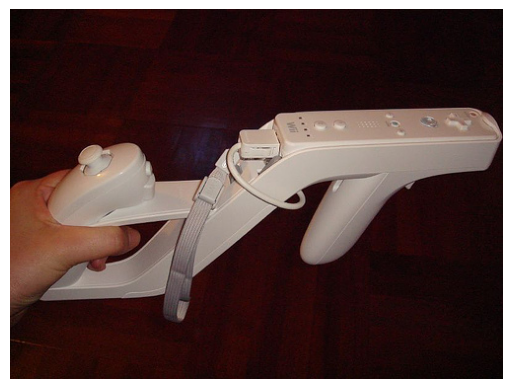

In [4]:
COCO_ROOT = "/kaggle/input/datasets/nadaibrahim/coco2014"
CACHE_DIR = "/kaggle/working/cache/hidden_states"
os.makedirs(CACHE_DIR, exist_ok=True)

random.seed(42)


img_dir = "/kaggle/input/datasets/nadaibrahim/coco2014/val2014/val2014"
print("images live in:", img_dir)

all_images = sorted(glob.glob(os.path.join(img_dir, "COCO_val2014_*.jpg")))
assert len(all_images) > 0, f"no COCO_val2014_*.jpg files found in {img_dir}"

random.seed(42)
all_images_shuffled = all_images.copy()
random.shuffle(all_images_shuffled)

BATCH_INDEX = 5
BATCH_SIZE = 70

IMAGE_PATHS = all_images_shuffled[BATCH_INDEX * BATCH_SIZE : (BATCH_INDEX + 1) * BATCH_SIZE]
print(f"batch {BATCH_INDEX}: {len(IMAGE_PATHS)} images")

CAPTION_PROMPT = "Describe this image in detail."
CAPTION_MAX_NEW_TOKENS = 100


def load_image(path):
    return Image.open(path).convert("RGB")


def build_inputs(image, text=CAPTION_PROMPT):
    conversation = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": text}]}]
    prompt_text = processor.apply_chat_template(conversation, add_generation_prompt=True)
    return processor(text=prompt_text, images=image, return_tensors="pt").to(model.device, torch.float16)


preview_image = load_image(IMAGE_PATHS[0])
plt.imshow(preview_image); plt.axis("off"); plt.show()

In [5]:
@torch.no_grad()
def cache_one_image(image_path, image_id):
    """Two-pass caching for one image. Returns a dict ready for torch.save."""
    image = load_image(image_path)
    inputs = build_inputs(image)
    prompt_len = inputs["input_ids"].shape[-1]

    # Pass 1 -- generate a caption
    gen_ids = model.generate(**inputs, max_new_tokens=CAPTION_MAX_NEW_TOKENS, do_sample=False)
    caption_text = processor.tokenizer.decode(gen_ids[0, prompt_len:], skip_special_tokens=True)

    # Pass 2 -- one teacher-forced pass over prompt + generated caption
    _encoder_cache.clear()
    full_attention_mask = torch.ones_like(gen_ids)
    outputs = model(
        input_ids=gen_ids,
        pixel_values=inputs["pixel_values"],
        attention_mask=full_attention_mask,
        output_hidden_states=True,
    )

    # position tagging
    full_len = gen_ids.shape[-1]
    image_token_id = model.config.image_token_index
    image_positions = (gen_ids[0] == image_token_id).nonzero(as_tuple=True)[0]

    all_positions = torch.arange(full_len)
    is_image = torch.zeros(full_len, dtype=torch.bool)
    is_image[image_positions] = True
    is_caption = all_positions >= prompt_len
    # prompt-text positions (the fixed instruction template) are neither -- drop them

    keep_positions = all_positions[is_image | is_caption]
    hidden_states = torch.stack([
        layer[0, keep_positions, :].half().cpu() for layer in outputs.hidden_states
    ])  # (n_layer+1, len(keep_positions), hidden_dim)

    target_probs = F.softmax(outputs.logits[0, keep_positions, :].float(), dim=-1).half().cpu()

    return {
        "image_id": image_id,
        "image_path": image_path,
        "caption_text": caption_text,
        "prompt_len": prompt_len,
        "full_len": full_len,
        "keep_positions": keep_positions,
        "is_image_at_keep": is_image[keep_positions],
        "is_caption_at_keep": is_caption[keep_positions],
        "hidden_states": hidden_states,
        "target_probs": target_probs,
        "encoder_patch_embeddings": _encoder_cache["patch_embeddings"],  # (1, 576, clip_hidden_dim), pre-projector
    }

In [6]:
"""
cache_paths = []
for i, path in enumerate(IMAGE_PATHS):
    image_id = os.path.splitext(os.path.basename(path))[0]
    entry = cache_one_image(path, image_id)

    out_path = os.path.join(CACHE_DIR, f"{image_id}.pt")
    torch.save(entry, out_path)
    cache_paths.append(out_path)

    if i == 0:
        size_mb = os.path.getsize(out_path) / 1e6
        projected_gb = size_mb * len(IMAGE_PATHS) / 1000
        print(f"first image cached -- {size_mb:.1f} MB/image.")
        print(f"at this rate, {len(IMAGE_PATHS)} images will use ~{projected_gb:.1f} GB. ")
    if i % 10 == 0:
        print(f"[{i+1}/{len(IMAGE_PATHS)}] {image_id}: {entry['caption_text']!r}")

print(f"done, {len(cache_paths)} images cached to {CACHE_DIR}")
"""

'\ncache_paths = []\nfor i, path in enumerate(IMAGE_PATHS):\n    image_id = os.path.splitext(os.path.basename(path))[0]\n    entry = cache_one_image(path, image_id)\n\n    out_path = os.path.join(CACHE_DIR, f"{image_id}.pt")\n    torch.save(entry, out_path)\n    cache_paths.append(out_path)\n\n    if i == 0:\n        size_mb = os.path.getsize(out_path) / 1e6\n        projected_gb = size_mb * len(IMAGE_PATHS) / 1000\n        print(f"first image cached -- {size_mb:.1f} MB/image.")\n        print(f"at this rate, {len(IMAGE_PATHS)} images will use ~{projected_gb:.1f} GB. ")\n    if i % 10 == 0:\n        print(f"[{i+1}/{len(IMAGE_PATHS)}] {image_id}: {entry[\'caption_text\']!r}")\n\nprint(f"done, {len(cache_paths)} images cached to {CACHE_DIR}")\n'

In [7]:
"""
@torch.no_grad()
def logit_lens_from_cache(entry, position_idx, top_k=5):
    n = entry["hidden_states"].shape[0]
    results = []
    for i in range(n):
        h = entry["hidden_states"][i, position_idx, :].to(lm_head.weight.device, torch.float16)
        if i < n - 1:
            h = ln_f(h)
        logits = lm_head(h)
        probs = torch.softmax(logits.float(), dim=-1)
        top_probs, top_ids = probs.topk(top_k)
        results.append([(processor.tokenizer.decode([tid]), float(p)) for tid, p in zip(top_ids.tolist(), top_probs.tolist())])
    return results


for path in cache_paths[:5]:
    entry = torch.load(path)
    last_pos = entry["hidden_states"].shape[1] - 1
    lens_logits = lm_head(entry["hidden_states"][-1, last_pos, :].to(lm_head.weight.device, torch.float16))
    lens_probs = torch.softmax(lens_logits.float(), dim=-1).cpu()
    real_probs = entry["target_probs"][last_pos, :].float()
    max_diff = (lens_probs - real_probs).abs().max().item()
    print(f"{entry['image_id']}: max prob diff vs cached target = {max_diff:.2e}")
    assert max_diff < 3e-2, "logit lens wiring isn't right, check ln_f/lm_head."
"""

'\n@torch.no_grad()\ndef logit_lens_from_cache(entry, position_idx, top_k=5):\n    n = entry["hidden_states"].shape[0]\n    results = []\n    for i in range(n):\n        h = entry["hidden_states"][i, position_idx, :].to(lm_head.weight.device, torch.float16)\n        if i < n - 1:\n            h = ln_f(h)\n        logits = lm_head(h)\n        probs = torch.softmax(logits.float(), dim=-1)\n        top_probs, top_ids = probs.topk(top_k)\n        results.append([(processor.tokenizer.decode([tid]), float(p)) for tid, p in zip(top_ids.tolist(), top_probs.tolist())])\n    return results\n\n\nfor path in cache_paths[:5]:\n    entry = torch.load(path)\n    last_pos = entry["hidden_states"].shape[1] - 1\n    lens_logits = lm_head(entry["hidden_states"][-1, last_pos, :].to(lm_head.weight.device, torch.float16))\n    lens_probs = torch.softmax(lens_logits.float(), dim=-1).cpu()\n    real_probs = entry["target_probs"][last_pos, :].float()\n    max_diff = (lens_probs - real_probs).abs().max().item()

In [8]:
"""
def plot_confidence_heatmap(image, confidence, title=""):
    side = model.config.vision_config.image_size // model.config.vision_config.patch_size
    grid = confidence.reshape(side, side)
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(image); axes[0].set_title("image"); axes[0].axis("off")
    im = axes[1].imshow(grid, cmap="viridis"); axes[1].set_title(title); axes[1].axis("off")
    fig.colorbar(im, ax=axes[1], fraction=0.046)
    plt.tight_layout(); plt.show()


@torch.no_grad()
def image_token_confidence_from_cache(entry, target_token, layer_idx=-1):
    ids = processor.tokenizer.encode(target_token.strip(), add_special_tokens=False)
    target_id = ids[-1]
    n = entry["hidden_states"].shape[0]
    idx = layer_idx % n
    image_mask = entry["is_image_at_keep"]
    h = entry["hidden_states"][idx, image_mask, :].to(lm_head.weight.device, torch.float16)
    if idx < n - 1:
        h = ln_f(h)
    logits = lm_head(h)
    probs = torch.softmax(logits.float(), dim=-1)
    return probs[:, target_id].cpu()


demo_entry = torch.load(cache_paths[0])
print("caption:", demo_entry["caption_text"])
demo_image = load_image(demo_entry["image_path"])
for word in [" gun", " nintendo", " floor"]:
    for layer in [10, 20, 25]:
        conf = image_token_confidence_from_cache(demo_entry, word, layer_idx=layer)
        plot_confidence_heatmap(demo_image, conf.numpy(), title=f"P({word.strip()!r})")
"""

'\ndef plot_confidence_heatmap(image, confidence, title=""):\n    side = model.config.vision_config.image_size // model.config.vision_config.patch_size\n    grid = confidence.reshape(side, side)\n    fig, axes = plt.subplots(1, 2, figsize=(10, 5))\n    axes[0].imshow(image); axes[0].set_title("image"); axes[0].axis("off")\n    im = axes[1].imshow(grid, cmap="viridis"); axes[1].set_title(title); axes[1].axis("off")\n    fig.colorbar(im, ax=axes[1], fraction=0.046)\n    plt.tight_layout(); plt.show()\n\n\n@torch.no_grad()\ndef image_token_confidence_from_cache(entry, target_token, layer_idx=-1):\n    ids = processor.tokenizer.encode(target_token.strip(), add_special_tokens=False)\n    target_id = ids[-1]\n    n = entry["hidden_states"].shape[0]\n    idx = layer_idx % n\n    image_mask = entry["is_image_at_keep"]\n    h = entry["hidden_states"][idx, image_mask, :].to(lm_head.weight.device, torch.float16)\n    if idx < n - 1:\n        h = ln_f(h)\n    logits = lm_head(h)\n    probs = torch

In [9]:
"""
!wget https://cs.stanford.edu/people/rak248/VG_100K/images.zip -O /kaggle/working/VG_100K.zip
!wget https://cs.stanford.edu/people/rak248/VG_100K_2/images2.zip -O /kaggle/working/VG_100K_2.zip
!unzip -q -o /kaggle/working/VG_100K.zip -d /kaggle/temp/
!unzip -q -o /kaggle/working/VG_100K_2.zip -d /kaggle/temp/
"""

'\n!wget https://cs.stanford.edu/people/rak248/VG_100K/images.zip -O /kaggle/working/VG_100K.zip\n!wget https://cs.stanford.edu/people/rak248/VG_100K_2/images2.zip -O /kaggle/working/VG_100K_2.zip\n!unzip -q -o /kaggle/working/VG_100K.zip -d /kaggle/temp/\n!unzip -q -o /kaggle/working/VG_100K_2.zip -d /kaggle/temp/\n'

In [10]:
AMBER_IMAGE_DIR = "/kaggle/input/datasets/nocturnalnerd18/amber-hallucination/image"
VG_IMAGE_DIRS = ["/kaggle/temp", "/kaggle/temp/VG_100K_2"]

def find_vg_image_path(image_id: str) -> str:
    for d in VG_IMAGE_DIRS:
        candidate = os.path.join(d, f"{image_id}.jpg")
        if os.path.exists(candidate):
            return candidate
    return None


def resolve_image_path(q: dict) -> str:
    qid = q["question_id"]
    if qid.startswith("pope_"):
        return os.path.join(img_dir, f"{q['image_id']}.jpg")
    elif qid.startswith("amber_"):
        return os.path.join(AMBER_IMAGE_DIR, f"{q['image_id']}.jpg")
    elif qid.startswith("reefknot_"):
        return find_vg_image_path(q["image_id"])
    return None

In [11]:
QUESTIONS_PATH = "/kaggle/input/datasets/nocturnalnerd18/vlm-questions/all_questions.json"

with open(QUESTIONS_PATH) as f:
    all_questions = json.load(f)

print(len(all_questions), "total questions loaded")

13230 total questions loaded


In [12]:
@torch.no_grad()
def cache_discriminative_question(image_path, image_id, question_id, question_text):
    image = load_image(image_path)
    inputs = build_inputs(image, text=question_text)
    prompt_len = inputs["input_ids"].shape[-1]

    _encoder_cache.clear()
    gen_ids = model.generate(**inputs, max_new_tokens=5, do_sample=False)
    answer_text = processor.tokenizer.decode(gen_ids[0, prompt_len:], skip_special_tokens=True).strip()

    full_attention_mask = torch.ones_like(gen_ids)
    outputs = model(
        input_ids=gen_ids, pixel_values=inputs["pixel_values"],
        attention_mask=full_attention_mask, output_hidden_states=True,
    )
    image_token_id = model.config.image_token_index
    image_positions = (gen_ids[0] == image_token_id).nonzero(as_tuple=True)[0]

    pooled_hidden_states = torch.stack([
        layer[0, image_positions, :].mean(dim=0).half().cpu() for layer in outputs.hidden_states
    ])
    pooled_encoder_embedding = _encoder_cache["patch_embeddings"].mean(dim=1).half()

    return {
        "image_id": image_id, "question_id": question_id, "question_text": question_text,
        "answer_text": answer_text,
        "pooled_hidden_states": pooled_hidden_states,
        "pooled_encoder_embedding": pooled_encoder_embedding,
    }

In [13]:
for q in all_questions[:5]:
    path = resolve_image_path(q)
    print(q["question_id"], "->", path, "exists:", path is not None and os.path.exists(path))
    if path and os.path.exists(path):
        entry = cache_discriminative_question(path, q["image_id"], q["question_id"], q["question_text"])
        print("  answer:", entry["answer_text"], "| hidden shape:", entry["pooled_hidden_states"].shape)

pope_0 -> /kaggle/input/datasets/nadaibrahim/coco2014/val2014/val2014/COCO_val2014_000000306812.jpg exists: True
  answer: Yes, there is a | hidden shape: torch.Size([33, 4096])
pope_1 -> /kaggle/input/datasets/nadaibrahim/coco2014/val2014/val2014/COCO_val2014_000000306812.jpg exists: True
  answer: No, there is no | hidden shape: torch.Size([33, 4096])
pope_2 -> /kaggle/input/datasets/nadaibrahim/coco2014/val2014/val2014/COCO_val2014_000000306812.jpg exists: True
  answer: Yes, there is a | hidden shape: torch.Size([33, 4096])
pope_3 -> /kaggle/input/datasets/nadaibrahim/coco2014/val2014/val2014/COCO_val2014_000000306812.jpg exists: True
  answer: No, there is no | hidden shape: torch.Size([33, 4096])
pope_4 -> /kaggle/input/datasets/nadaibrahim/coco2014/val2014/val2014/COCO_val2014_000000306812.jpg exists: True
  answer: Yes, there is a | hidden shape: torch.Size([33, 4096])


In [14]:
def publish_discriminative_cache(dataset_slug, username):
    metadata = {
        "title": dataset_slug,
        "id": f"{username}/{dataset_slug}",
        "licenses": [{"name": "CC0-1.0"}]
    }
    with open(os.path.join(DISCRIMINATIVE_CACHE_DIR, "dataset-metadata.json"), "w") as f:
        json.dump(metadata, f)
    os.system(f"kaggle datasets create -p {DISCRIMINATIVE_CACHE_DIR}")


def clear_discriminative_cache():
    import shutil
    shutil.rmtree(DISCRIMINATIVE_CACHE_DIR, ignore_errors=True)
    os.makedirs(DISCRIMINATIVE_CACHE_DIR, exist_ok=True)


USERNAME = "nocturnalnerd18"

In [15]:
import time

DISCRIMINATIVE_CACHE_DIR = "/kaggle/working/cache/discriminative"
os.makedirs(DISCRIMINATIVE_CACHE_DIR, exist_ok=True)

SOURCE_FILTER = "amber_"
questions_subset = [q for q in all_questions if q["question_id"].startswith(SOURCE_FILTER)]

BATCH_SAVE_SIZE = 200
batch_entries, batch_index, skipped = [], 0, 0
t_start = time.time()

for i, q in enumerate(questions_subset):
    image_path = resolve_image_path(q)
    if image_path is None or not os.path.exists(image_path):
        skipped += 1
        continue

    entry = cache_discriminative_question(image_path, q["image_id"], q["question_id"], q["question_text"])
    entry.update({k: q[k] for k in ("ground_truth_answer", "answer_format", "hallucination_type")})
    batch_entries.append(entry)

    if len(batch_entries) >= BATCH_SAVE_SIZE:
        torch.save(batch_entries, os.path.join(DISCRIMINATIVE_CACHE_DIR, f"{SOURCE_FILTER}batch_{batch_index}.pt"))
        batch_entries, batch_index = [], batch_index + 1

    if i % 100 == 0 and i > 0:
        elapsed = time.time() - t_start
        avg = elapsed / (i + 1)
        remaining = avg * (len(questions_subset) - i - 1)
        print(f"[{i+1}/{len(questions_subset)}] {q['question_id']}: {entry['answer_text']!r} "
              f"({avg:.2f}s/question avg, ETA {remaining/60:.1f} min, skipped: {skipped})")

if batch_entries:
    torch.save(batch_entries, os.path.join(DISCRIMINATIVE_CACHE_DIR, f"{SOURCE_FILTER}batch_{batch_index}.pt"))

print(f"done -- {batch_index + 1} files for {SOURCE_FILTER}, {skipped} skipped, {(time.time()-t_start)/60:.1f} min total")

[101/9292] amber_1105: 'No, there are two' (1.16s/question avg, ETA 177.5 min, skipped: 0)
[201/9292] amber_1205: 'Yes, there are two' (1.20s/question avg, ETA 182.2 min, skipped: 0)
[301/9292] amber_1305: 'Yes, the cloud in' (1.21s/question avg, ETA 181.9 min, skipped: 0)
[401/9292] amber_1405: 'Yes, there is one' (1.22s/question avg, ETA 180.8 min, skipped: 0)
[501/9292] amber_1505: 'Yes, there is one' (1.22s/question avg, ETA 179.4 min, skipped: 0)
[601/9292] amber_1605: 'Yes, the person in' (1.23s/question avg, ETA 177.7 min, skipped: 0)
[701/9292] amber_1705: 'Yes, the dog runs' (1.23s/question avg, ETA 175.9 min, skipped: 0)
[801/9292] amber_1805: 'Yes, the person in' (1.23s/question avg, ETA 174.0 min, skipped: 0)
[901/9292] amber_1905: 'Yes, the beach in' (1.23s/question avg, ETA 172.1 min, skipped: 0)
[1001/9292] amber_2005: 'Yes, the person is' (1.23s/question avg, ETA 170.2 min, skipped: 0)
[1101/9292] amber_2105: 'Yes, there are two' (1.23s/question avg, ETA 168.2 min, skip

In [16]:
publish_discriminative_cache("discriminative-cache-amber", USERNAME)
clear_discriminative_cache()

Starting upload for file amber_batch_16.pt


100%|██████████| 52.1M/52.1M [00:03<00:00, 15.1MB/s]


Upload successful: amber_batch_16.pt (52MB)
Starting upload for file amber_batch_5.pt


100%|██████████| 52.1M/52.1M [00:03<00:00, 15.0MB/s]


Upload successful: amber_batch_5.pt (52MB)
Starting upload for file amber_batch_36.pt


...

Upload successful: amber_batch_22.pt (52MB)
Starting upload for file amber_batch_21.pt


100%|██████████| 52.1M/52.1M [00:04<00:00, 13.4MB/s]


Upload successful: amber_batch_21.pt (52MB)
Starting upload for file amber_batch_30.pt


100%|██████████| 52.1M/52.1M [00:04<00:00, 13.4MB/s]


Upload successful: amber_batch_30.pt (52MB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/nocturnalnerd18/discriminative-cache-amber
